In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from pathlib import Path
from scipy.stats import chi2_contingency, ttest_ind
import warnings
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
PROJECT_ROOT = ROOT
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
TABLE_DIR = OUTPUTS_DIR / 'tables'
FIG_DIR = OUTPUTS_DIR / 'figures'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
# Chargement du jeu de données préparé
df = pd.read_excel('Dataset_Malnutrition_Cameroun_2018.xlsx', sheet_name='data')
print("Dimensions du dataset:", df.shape)


Dimensions du dataset: (3806, 22)


In [3]:
# Analyses univariées (Variables quantitatives)
quant_vars = ['age_mere', 'imc_mere', 'age_enfant_mois', 'rang_naissance', 'intervalle_naissance']
df[quant_vars].describe().to_csv(TABLE_DIR / 'statistiques_descriptives.csv')
display(df[quant_vars].describe())


,age_mere,imc_mere,age_enfant_mois,rang_naissance,intervalle_naissance
count,3806.000000,3806.000000,3806.000000,3806.000000,3806.000000
mean,28.361272,24.327199,28.739096,3.492118,28.622438
std,6.553254,4.923343,17.224314,2.320863,24.650953
min,15.000000,14.350000,0.000000,1.000000,0.000000
25%,23.000000,20.950000,14.000000,2.000000,12.000000
50%,28.000000,23.340000,28.000000,3.000000,26.000000
75%,33.000000,26.740000,44.000000,5.000000,39.000000
max,49.000000,48.770000,59.000000,14.000000,183.000000


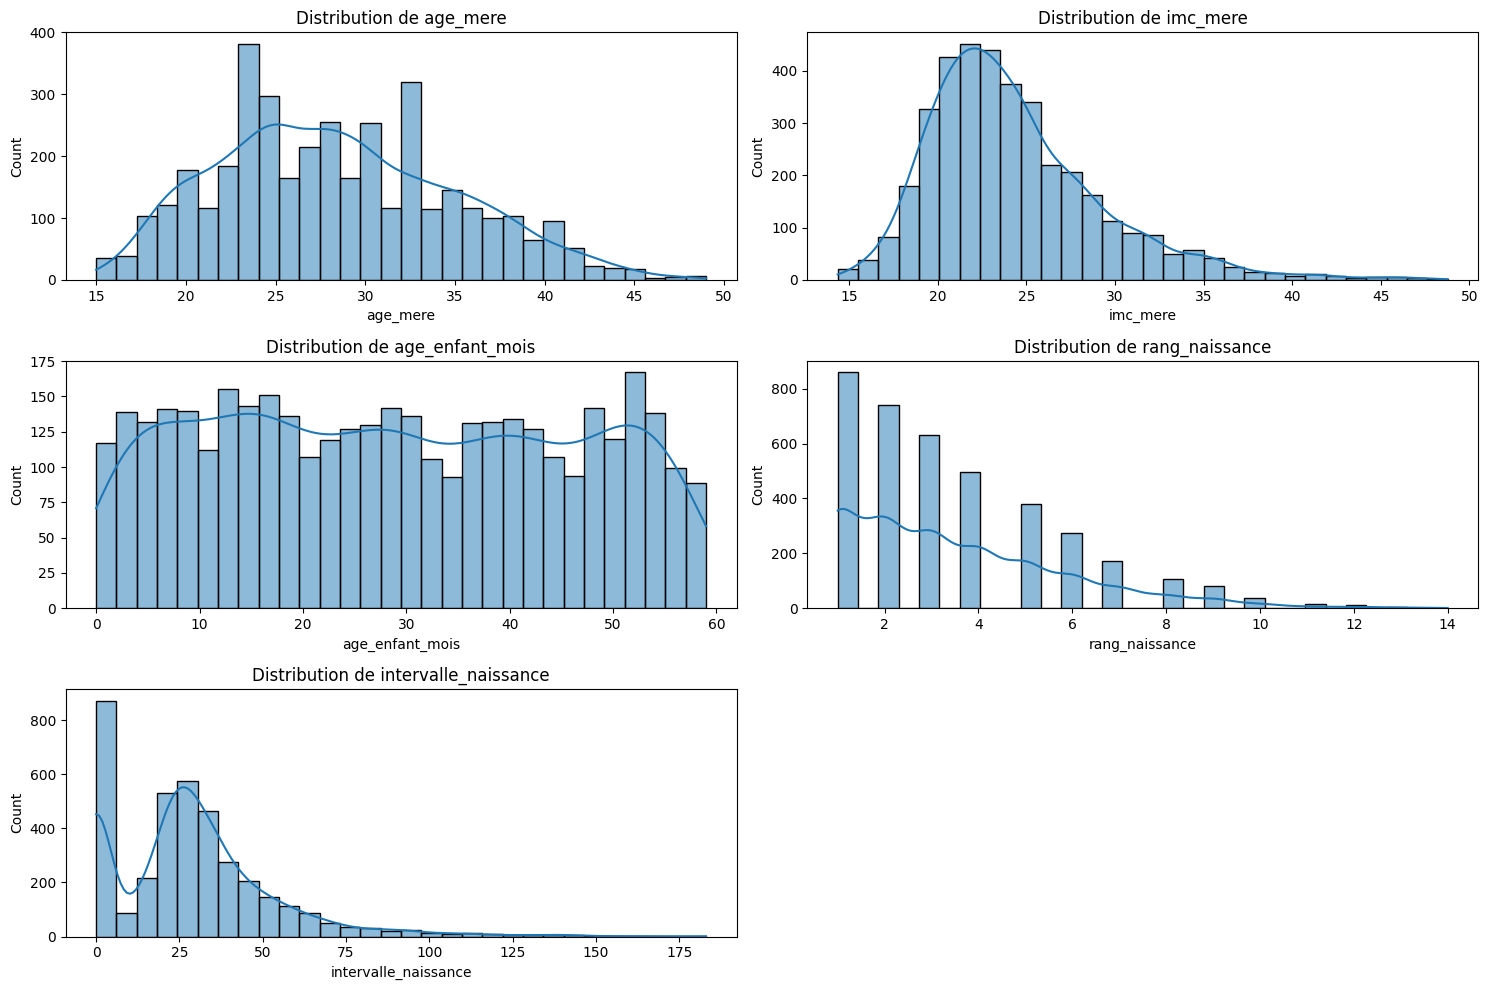

In [4]:
# Visualisation des distributions
plt.figure(figsize=(15, 10))
for i, var in enumerate(quant_vars, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df[var], kde=True, bins=30)
    plt.title(f'Distribution de {var}')
plt.tight_layout()
plt.savefig(FIG_DIR / 'distributions_quantitatives.png')
plt.show()


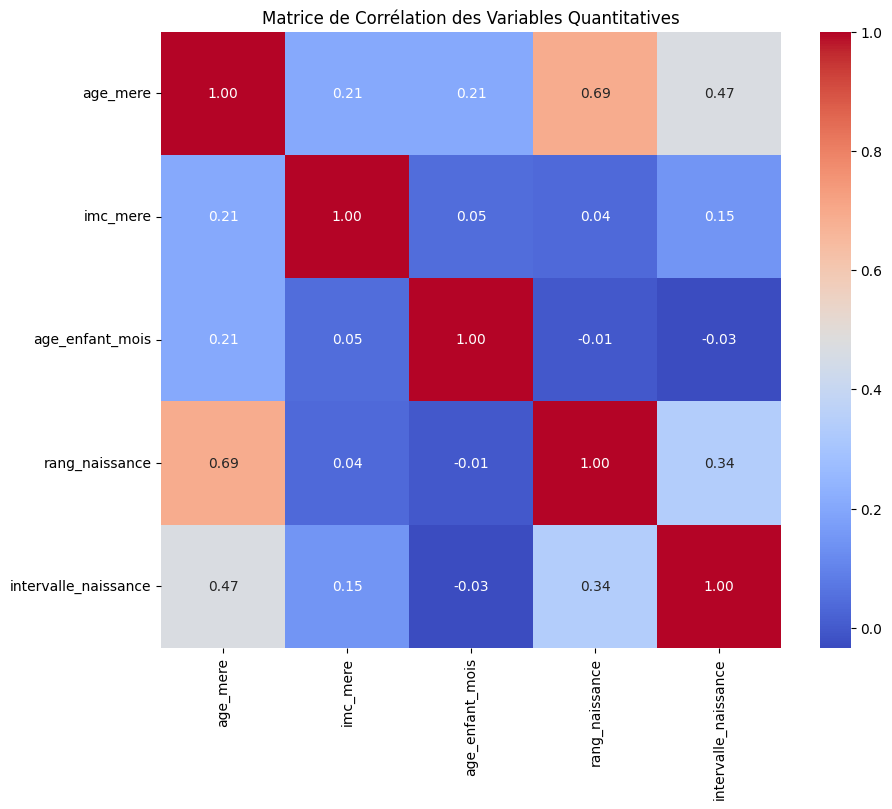

In [5]:
# Matrice de corrélation (uniquement sur variables quantitatives)
plt.figure(figsize=(10, 8))
corr = df[quant_vars].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation des Variables Quantitatives")
plt.savefig(FIG_DIR / 'correlation_quantitatives.png')
plt.show()


In [6]:
# Analyses bivariées (Qualitatives vs Y_global_malnutrition)
qual_vars = ['region', 'milieu_residence', 'education_mere', 'index_richesse', 'sexe_enfant']

for var in qual_vars:
    contingency = pd.crosstab(df[var], df['Y_global_malnutrition'])
    chi2, p, dof, ex = chi2_contingency(contingency)
    print(f"Test Chi-Deux pour {var} vs Malnutrition: p-value = {p:.4f}")
    
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=var, hue='Y_global_malnutrition')
    plt.title(f'Malnutrition globale selon {var}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'bivarie_{var}_vs_malnutrition.png')
    plt.close()


Test Chi-Deux pour region vs Malnutrition: p-value = 0.0000
Test Chi-Deux pour milieu_residence vs Malnutrition: p-value = 0.0000
Test Chi-Deux pour education_mere vs Malnutrition: p-value = 0.0000
Test Chi-Deux pour index_richesse vs Malnutrition: p-value = 0.0000
Test Chi-Deux pour sexe_enfant vs Malnutrition: p-value = 0.0000


In [7]:
# Construction du Modèle Statistique Pondéré
# 1. Préparation des X (Variables indépendantes)
# On convertit les qualitatives en dummies, en évitant les variables cibles (Y) dans X.
X_cols = quant_vars + qual_vars
X = pd.get_dummies(df[X_cols], drop_first=True, columns=qual_vars)

# Suppression des colonnes avec une variance très faible ou constantes
X = X.loc[:, X.var() > 0.0]

# Suppression des variables hautement colinéaires (>0.85)
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
X = X.drop(columns=to_drop)

X = sm.add_constant(X)

# 2. Les 3 modèles de base
targets = ['Y1_retard_croissance', 'Y2_amaigrissement', 'Y3_insuffisance_ponderale']
models = {}
predictions = pd.DataFrame(index=df.index)

for t in targets:
    print(f"\n--- Modèle pour {t} ---")
    y = df[t]
    try:
        model = sm.Logit(y, X.astype(float)).fit(method='bfgs', maxiter=200, disp=0)
    except Exception as e:
        print("BFGS failed, trying newton...", e)
        model = sm.Logit(y, X.astype(float)).fit(disp=0)
    models[t] = model
    predictions[f'prob_{t}'] = model.predict(X.astype(float))
    
    # Save summaries
    with open(TABLE_DIR / f'resume_modele_{t}.txt', 'w') as f:
        f.write(model.summary().as_text())
        
# 3. Méta-modèle pour la variable globale (Stacking Statistique)
print("\n--- Modèle Global Pondéré (Méta-Modèle) ---")
X_meta = sm.add_constant(predictions)
y_global = df['Y_global_malnutrition']
meta_model = sm.Logit(y_global, X_meta).fit(disp=0)

# Save global summary
with open(TABLE_DIR / 'resume_meta_modele.txt', 'w') as f:
    f.write(meta_model.summary().as_text())
    
print(meta_model.summary())

# Odd Ratios du méta-modèle (Poids des 3 sous-modèles sur la décision finale)
or_meta = np.exp(meta_model.params)
print("\nOdds Ratios du Méta-Modèle :\n", or_meta)
or_meta.to_csv(TABLE_DIR / 'odds_ratios_meta_modele.csv')



--- Modèle pour Y1_retard_croissance ---

--- Modèle pour Y2_amaigrissement ---

--- Modèle pour Y3_insuffisance_ponderale ---

--- Modèle Global Pondéré (Méta-Modèle) ---
                             Logit Regression Results                            
Dep. Variable:     Y_global_malnutrition   No. Observations:                 3806
Model:                             Logit   Df Residuals:                     3802
Method:                              MLE   Df Model:                            3
Date:                   Fri, 22 May 2026   Pseudo R-squ.:                 0.08305
Time:                           10:28:13   Log-Likelihood:                -2169.4
converged:                          True   LL-Null:                       -2365.9
Covariance Type:               nonrobust   LLR p-value:                 7.332e-85
                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------